            # eReefs live OPeNDAP demo

            This notebook demonstrates remote access without downloading the full NetCDF files locally. It focuses on the main live workflows:

            - NCI `simple` file access through OPeNDAP
            - grid discovery for centre-only products
            - standard and smoother map rendering
            - time-aware catalog resolution across AIMS monthly files
            - surface time series across multiple live monthly files
            - vertical profiles, vertical slices, and surface transects from live data
            - depth-aware extraction when `eta` is absent
            - a short whole-of-GBR `map_ereefs_movie()` example
            


In [2]:
            repo_root <- normalizePath(if (basename(getwd()) == "notebooks") ".." else ".", winslash = "/")
            setwd(repo_root)
            .libPaths(c(normalizePath(".r_libs", winslash = "/", mustWork = FALSE), .libPaths()))

            suppressPackageStartupMessages({
              library(pkgload)
              library(dplyr)
              library(ggplot2)
              library(tibble)
            })

            pkgload::load_all(".")

            aims_catalog <- "https://thredds.ereefs.aims.gov.au/thredds/catalog/ereefs/gbr1_2.0/stats-monthly-monthly/catalog.xml"
            nci_catalog <- "https://thredds.nci.org.au/thredds/catalog/fx3/gbr4_H4p0_ABARRAr2_OBRAN2020_FG2Gv3_B4p2_Cq5b_Dhnd/catalog.xml"
            nci_simple <- "https://thredds.nci.org.au/thredds/dodsC/fx3/gbr4_H4p0_ABARRAr2_OBRAN2020_FG2Gv3_B4p2_Cq5b_Dhnd/gbr4_H4p0_ABARRAr2_OBRAN2020_FG2G_B4p2_Cq5b_Dhnd_simple_2022-10-30.nc"
            


Warning message:
"package 'dplyr' was built under R version 4.3.3"
Warning message:
"package 'tibble' was built under R version 4.3.3"
ℹ Loading ereefs


In [3]:
            notebook_output_dir <- file.path(repo_root, "notebooks", "output", "live_demo")
            dir.create(notebook_output_dir, recursive = TRUE, showWarnings = FALSE)

            save_plot_display <- function(plot_obj, filename, width = 8, height = 6, dpi = 120) {
              out_path <- file.path(notebook_output_dir, filename)
              ggplot2::ggsave(out_path, plot = plot_obj, width = width, height = height, dpi = dpi)
              print(plot_obj)
              out_path
            }

            display_animation_file <- function(path) {
              if (is.na(path) || !file.exists(path)) {
                return(invisible(path))
              }
              if (grepl("\\.gif$", path, ignore.case = TRUE) && requireNamespace("magick", quietly = TRUE)) {
                print(magick::image_read(path))
              } else {
                cat(path, "\n")
              }
              invisible(path)
            }
            


            This block inspects the NCI simple file grid metadata, including the reconstructed plotting geometry used for centre-based live products.
            


In [4]:
            nci_grids <- get_ereefs_grids(nci_simple)
            tibble(
              grid_type = nci_grids$grid_type,
              n_cells = nrow(nci_grids$spatial_grid),
              x_grid_rows = nrow(nci_grids$x_grid),
              x_grid_cols = ncol(nci_grids$x_grid)
            )
            


Warning message in ereefs_reconstruct_z_grid_from_zc(zc = ereefs_read_var_array(source_file, :
"z_grid was not available in https://thredds.nci.org.au/thredds/dodsC/fx3/gbr4_H4p0_ABARRAr2_OBRAN2020_FG2Gv3_B4p2_Cq5b_Dhnd/gbr4_H4p0_ABARRAr2_OBRAN2020_FG2G_B4p2_Cq5b_Dhnd_simple_2022-10-30.nc. Reconstructing layer interfaces from zc, assuming interior interfaces lie midway between zc values and setting the upper interface to 1e20 to match the standard EMS convention."


grid_type,n_cells,x_grid_rows,x_grid_cols
<chr>,<int>,<int>,<int>
curvilinear,108000,601,181


            These two maps show the same NCI Secchi field with polygon rendering and the optional smoother display mode.
            


[1] "C:/Users/brobson/OneDrive - Australian Institute of Marine Science/Code/eReefs R toolkit/ereefs/notebooks/output/live_demo/nci_secchi_polygon.png"

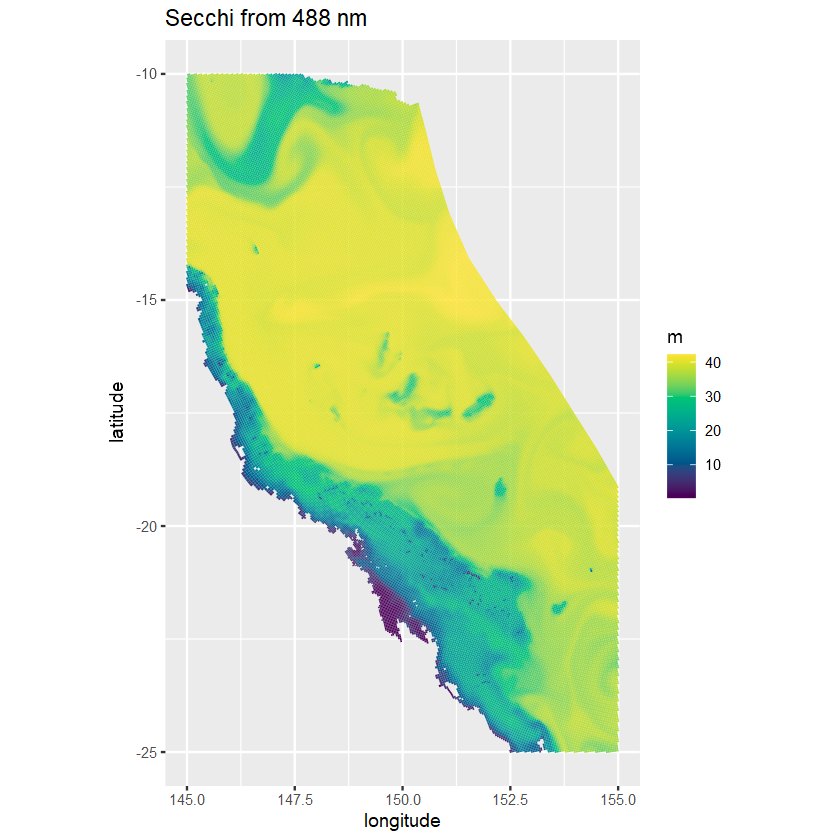

[1] "C:/Users/brobson/OneDrive - Australian Institute of Marine Science/Code/eReefs R toolkit/ereefs/notebooks/output/live_demo/nci_secchi_smooth.png"

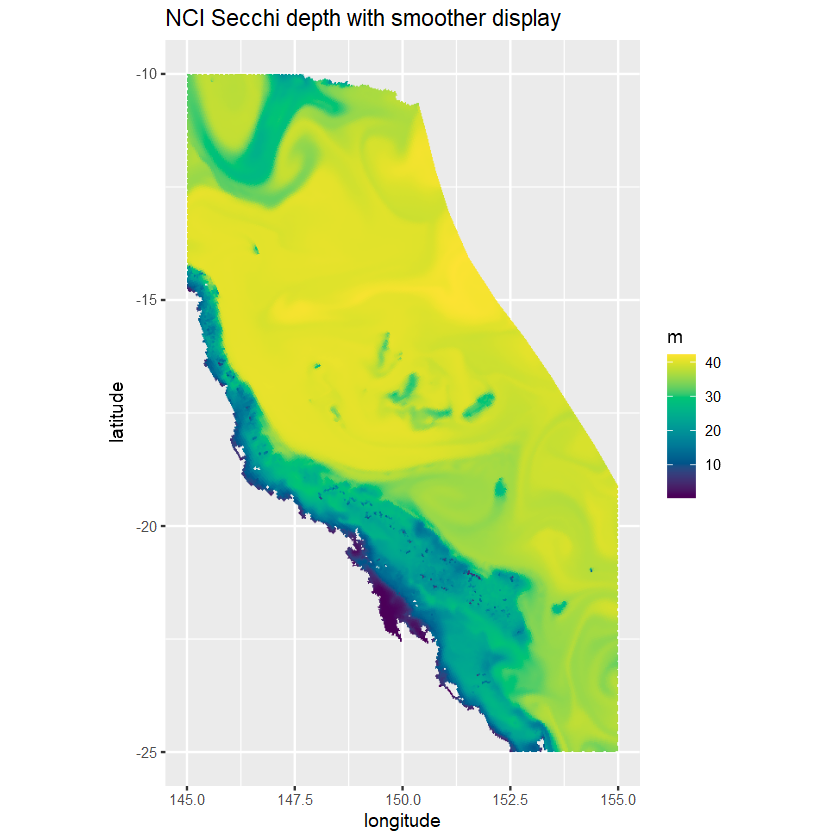

In [5]:
            nci_box <- c(145, 155, -25, -10)

            nci_map <- map_ereefs(
              var_name = "Secchi",
              target_date = as.Date("2022-10-30"),
              input_file = nci_simple,
              box_bounds = nci_box,
              scale_col = "viridis",
              suppress_print = TRUE,
              return_poly = TRUE,
              label_towns = FALSE
            )

            nci_map_plot <- plot_map(
              nci_map,
              box_bounds = nci_box,
              scale_col = "viridis",
              suppress_print = TRUE,
              label_towns = FALSE
            )
            save_plot_display(nci_map_plot, "nci_secchi_polygon.png")

            nci_map_smooth <- plot_map(
              nci_map,
              box_bounds = nci_box,
              scale_col = "viridis",
              plot_style = "smooth",
              smooth_pixels = 500,
              suppress_print = TRUE,
              label_towns = FALSE,
              var_longname = "NCI Secchi depth with smoother display"
            )
            save_plot_display(nci_map_smooth, "nci_secchi_smooth.png")
            


            Here we compare a direct surface extraction from the NCI simple file with a depth-below-free-surface extraction that has to assume `eta = 0`.
            


In [6]:
            live_surface <- get_ereefs_ts(
              var_names = "Secchi",
              geocoordinates = tibble(latitude = -19.5, longitude = 148.0),
              start_date = as.POSIXct("2022-10-30 00:00:00", tz = "Etc/GMT-10"),
              end_date = as.POSIXct("2022-10-30 23:59:59", tz = "Etc/GMT-10"),
              input_file = nci_simple,
              verbosity = 0
            )

            eta_warning <- NULL
            live_depth <- withCallingHandlers(
              get_ereefs_depth_specified_ts(
                var_names = "NH4",
                geocoordinates = tibble(latitude = -19.5, longitude = 148.0),
                depth = 2,
                start_date = as.POSIXct("2022-10-30 00:00:00", tz = "Etc/GMT-10"),
                end_date = as.POSIXct("2022-10-30 23:59:59", tz = "Etc/GMT-10"),
                input_file = nci_simple,
                verbosity = 0
              ),
              warning = function(w) {
                eta_warning <<- conditionMessage(w)
                invokeRestart("muffleWarning")
              }
            )

            list(
              surface_head = head(live_surface),
              depth_head = head(live_depth),
              no_eta_warning = eta_warning
            )
            


latitude,longitude,i,j,cell_latitude,cell_longitude,time,Secchi
<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dttm>,<dbl>
-19.5,148,302,34,-19.5055,147.9894,2022-10-30 12:00:00,24.66364
latitude,longitude,i,j,cell_latitude,cell_longitude,time,NH4
<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dttm>,<dbl>
-19.5,148,302,34,-19.5055,147.9894,2022-10-30 12:00:00,0.01771754


            This example resolves a two-month time series across the live NCI catalog rather than a single file and then plots the extracted surface ammonium series.
            


In [ ]:
            nci_surface_warning <- NULL
            nci_surface_ts <- withCallingHandlers(
              get_ereefs_ts(
                var_names = "NH4",
                geocoordinates = tibble(latitude = -19.5, longitude = 148.0),
                layer = "surface",
                start_date = as.POSIXct("2022-09-01 00:00:00", tz = "Etc/GMT-10"),
                end_date = as.POSIXct("2022-10-30 23:59:59", tz = "Etc/GMT-10"),
                input_file = nci_catalog,
                verbosity = 0
              ),
              warning = function(w) {
                if (is.null(nci_surface_warning) &&
                    grepl("assuming eta = 0", conditionMessage(w), fixed = TRUE)) {
                  nci_surface_warning <<- conditionMessage(w)
                }
                invokeRestart("muffleWarning")
              }
            )

            attr(nci_surface_ts, "warning_text") <- nci_surface_warning

            nci_surface_ts_plot <- ggplot(nci_surface_ts, aes(x = time, y = NH4)) +
              geom_line(colour = "#00798c", linewidth = 0.8) +
              geom_point(colour = "#d1495b", size = 0.9) +
              labs(
                title = "Two-month live surface time series",
                x = NULL,
                y = "Surface NH4 (mg N m-3)"
              ) +
              theme_minimal(base_size = 12)
            save_plot_display(nci_surface_ts_plot, "nci_surface_timeseries.png", width = 9, height = 5)
            


            This block asks the AIMS monthly catalog which files are needed to span the requested period.
            


In [ ]:
            aims_files <- ereefs_resolve_time_files(
              aims_catalog,
              as.Date("2019-10-01"),
              as.Date("2019-12-31")
            )
            aims_files
            


file_date,opendap_url
<date>,<chr>
2019-10-01,https://thredds.ereefs.aims.gov.au/thredds/dodsC/ereefs/gbr1_2.0/stats-monthly-monthly/EREEFS_AIMS-CSIRO_gbr1_2.0_hydro_stats_monthly-monthly-2019-10.nc
2019-11-01,https://thredds.ereefs.aims.gov.au/thredds/dodsC/ereefs/gbr1_2.0/stats-monthly-monthly/EREEFS_AIMS-CSIRO_gbr1_2.0_hydro_stats_monthly-monthly-2019-11.nc
2019-12-01,https://thredds.ereefs.aims.gov.au/thredds/dodsC/ereefs/gbr1_2.0/stats-monthly-monthly/EREEFS_AIMS-CSIRO_gbr1_2.0_hydro_stats_monthly-monthly-2019-12.nc


            We then map one AIMS monthly field to show the regular-grid live workflow over a large spatial domain.
            


In [ ]:
            aims_box <- c(142.0, 155.4, -28.7, -7.3)
            aims_map <- map_ereefs(
              var_name = "temp_mean",
              target_date = as.Date("2019-10-01"),
              layer = "surface",
              input_file = aims_catalog,
              box_bounds = aims_box,
              scale_col = "viridis",
              suppress_print = TRUE,
              return_poly = TRUE,
              label_towns = FALSE
            )

            aims_map_plot <- plot_map(
              aims_map,
              box_bounds = aims_box,
              scale_col = "viridis",
              plot_style = "smooth",
              smooth_pixels = 500,
              suppress_print = FALSE,
              label_towns = FALSE
            )
            save_plot_display(aims_map_plot, "aims_surface_map_smooth.png")
            


ERROR: Error in map_ereefs(var_name = "temp_mean", target_date = as.Date("2019-10-01"), : could not find function "map_ereefs"


            The next block extracts a vertical profile from the live NCI simple file at one geographic location and plots the depth structure.
            


In [ ]:
            live_profile <- get_ereefs_profile(
              var_names = "NH4",
              geolocation = c(-19.5, 148.0),
              start_date = as.POSIXct("2022-10-30 12:00:00", tz = "Etc/GMT-10"),
              end_date = as.POSIXct("2022-10-30 12:00:00", tz = "Etc/GMT-10"),
              input_file = nci_simple
            )

            live_profile_plot <- plot_ereefs_profile(
              live_profile,
              var_name = "NH4",
              target_date = as.Date("2022-10-30")
            )
            save_plot_display(live_profile_plot, "nci_vertical_profile.png")
            


            This block extracts a vertical slice along a short transect and plots the resulting section.
            


In [ ]:
            transect_line <- data.frame(
              latitude = c(-19.55, -19.50),
              longitude = c(147.95, 148.05)
            )

            live_slice <- get_ereefs_slice(
              var_names = "NH4",
              geolocation = transect_line,
              target_date = as.POSIXct("2022-10-30 12:00:00", tz = "Etc/GMT-10"),
              input_file = nci_simple
            )

            live_slice_plot <- plot_ereefs_slice(live_slice, var_name = "NH4", scale_col = "viridis", var_units = "mg N m-3")
            save_plot_display(live_slice_plot, "nci_vertical_slice.png", width = 9, height = 5)
            


            Here we densify the transect, match it to nearby cells, and plot the resulting surface transect as a one-dimensional series along distance.
            


In [ ]:
            transect_cells <- ereefs_densify_path(transect_line, samples_per_segment = 60) %>%
              ereefs_nearest_cells(get_ereefs_grids(nci_simple)$spatial_grid) %>%
              dplyr::distinct(i, j, .keep_all = TRUE)

            surface_transect <- get_ereefs_ts(
              var_names = "NH4",
              geocoordinates = transect_cells %>% dplyr::select(latitude, longitude),
              layer = "surface",
              start_date = as.POSIXct("2022-10-30 12:00:00", tz = "Etc/GMT-10"),
              end_date = as.POSIXct("2022-10-30 12:00:00", tz = "Etc/GMT-10"),
              input_file = nci_simple,
              verbosity = 0
            ) %>%
              dplyr::mutate(
                distance_km = c(
                  0,
                  cumsum(vapply(
                    seq_len(dplyr::n() - 1),
                    function(idx) earth.dist(
                      longitude[[idx]],
                      latitude[[idx]],
                      longitude[[idx + 1]],
                      latitude[[idx + 1]]
                    ),
                    numeric(1)
                  ))
                )
              )

            surface_transect_plot <- ggplot(surface_transect, aes(x = distance_km, y = NH4)) +
              geom_line(colour = "#2a6f97", linewidth = 0.8) +
              geom_point(colour = "#f4a261", size = 1.7) +
              labs(
                title = "Surface transect from live OPeNDAP data",
                x = "Distance along transect (km)",
                y = "Surface NH4 (mg N m-3)"
              ) +
              theme_minimal(base_size = 12)
            save_plot_display(surface_transect_plot, "nci_surface_transect.png", width = 9, height = 5)
            


            The closing example builds a short whole-of-GBR movie from AIMS monthly files, saves each frame, and shows the summary output plus animation artifact.
            


In [ ]:
            movie_output_dir <- file.path(notebook_output_dir, "movie_frames")
            movie_demo <- map_ereefs_movie(
              var_name = "temp_mean",
              start_date = as.Date("2019-10-01"),
              end_date = as.Date("2019-11-01"),
              layer = "surface",
              output_dir = movie_output_dir,
              save_frames = TRUE,
              animation_format = "gif",
              input_file = aims_catalog,
              box_bounds = aims_box,
              plot_style = "smooth",
              smooth_pixels = 220,
              stride = 31,
              suppress_print = TRUE,
              fps = 1,
              label_towns = FALSE
            )

            movie_summary_plot <- plot_map(
              movie_demo,
              box_bounds = aims_box,
              scale_col = "viridis",
              plot_style = "smooth",
              smooth_pixels = 220,
              suppress_print = TRUE,
              label_towns = FALSE,
              var_longname = "Average surface temperature across the selected frames",
              var_units = "degC"
            )
            save_plot_display(movie_summary_plot, "aims_movie_summary.png")
            display_animation_file(movie_demo$animation_file)
            list(
              animation_file = movie_demo$animation_file,
              n_frames = length(movie_demo$frame_files),
              frame_dir = movie_demo$output_dir
            )
            
